# VMGP: Variational Auto-Encoder Multi-task Genomic Prediction
## Training & Risultati

Questo notebook utilizza il modulo `vae/` per training e analisi.

### Struttura del Modulo:
- `vae/network.py` - Architettura VMGP
- `vae/lightning_module.py` - Logic training (PyTorch Lightning)
- `vae/data_module.py` - Caricamento e preprocessing dati PLINK
- `vae/utils.py` - Funzioni di utilità (balancing, metriche)
- `vae/experiment.py` - Runner esperimenti con K-Fold CV
- `vae/analysis.py` - Analisi post-training

---

## 1. Setup e Imports

In [1]:
import os
import sys
import torch
import pandas as pd
import pytorch_lightning as pl

# Aggiungi la directory parent al path per importare il modulo vae
sys.path.insert(0, os.path.dirname(os.getcwd()))

# Imposta seed per riproducibilità
pl.seed_everything(42)
# Import modulo VAE
from vae import (
    VMGP_Network,
    VMGP_LightningSystem,
    GenomicDataModule,
    run_experiment,
    CLASSIFIER_CONFIGS,
    analyze_model_performance
)

print("✅ Moduli caricati correttamente!")
print(f"🔧 CUDA disponibile: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

Seed set to 42


✅ Moduli caricati correttamente!
🔧 CUDA disponibile: True
   GPU: NVIDIA GeForce RTX 5070 Ti


## 2. Configurazione

In [2]:
# ⚠️ MODIFICA QUESTI PATH CON IL TUO DATASET ⚠️
BED_PATH = "../data/ADAPTmap_genotypeTOP_20160222_full.bed"
METADATA_PATH = "classificazione-capre.csv"

# Coarse Grained Mapping
COARSE_MAPPING = {
    'LATTE': ['ALP', 'ARG', 'ASP', 'BIO', 'CRS', 'GGT', 'KLS', 'LNR', 'MLG', 'MLS', 'MLT', 'MUG', 'NIC', 'ORO', 'PTV', 'RME', 'SAA', 'SAR', 'TOG', 'VSS', 'NRW'],
    'FIBRA': ['ANG', 'ANK', 'CAS'],
    'CARNE': ['BOE', 'RAN', 'TED', 'BRI', 'BEY', 'MOX', 'RAS', 'THA']
}

# Hyperparameters
config = {
    # DataModule
    'bed_path': BED_PATH,
    'metadata_path': METADATA_PATH,
    'batch_size': 32,
    'maf_thresh': 0.01,
    'geno_thresh': 0.1,
    'min_samples_per_class': 10,
    'ld_pruning': True,
    'ld_threshold': 0.2,
    'ld_window': 50,
    'val_split': 0.15,
    'test_split': 0.15,
    
    # Balancing
    'target_samples': 50,
    
    # Model (VMGP) - Loss weights
    'alpha': 0.5,
    'lr': 0.0001,
    
    # Pesi relativi dei classificatori
    'weight_breed': 1.0,
    'weight_continent': 1.0,
    'weight_caseina': 1.0,
    
    # Training
    'max_epochs': 100,
    'accelerator': 'gpu' if torch.cuda.is_available() else 'cpu',
    'devices': 1,
}

print("📋 CONFIGURAZIONE:")
for k, v in config.items():
    print(f"   {k}: {v}")

print("\n📊 CONFIGURAZIONI CLASSIFICATORI DISPONIBILI:")
for name, cfg in CLASSIFIER_CONFIGS.items():
    print(f"   {name}: {cfg['description']}")

📋 CONFIGURAZIONE:
   bed_path: ../data/ADAPTmap_genotypeTOP_20160222_full.bed
   metadata_path: classificazione-capre.csv
   batch_size: 32
   maf_thresh: 0.01
   geno_thresh: 0.1
   min_samples_per_class: 10
   ld_pruning: True
   ld_threshold: 0.2
   ld_window: 50
   val_split: 0.15
   test_split: 0.15
   target_samples: 50
   alpha: 0.5
   lr: 0.0001
   weight_breed: 1.0
   weight_continent: 1.0
   weight_caseina: 1.0
   max_epochs: 100
   accelerator: gpu
   devices: 1

📊 CONFIGURAZIONI CLASSIFICATORI DISPONIBILI:
   breed_only: Solo classificatore Breed (razza)
   continent_only: Solo classificatore Continent
   caseina_only: Solo classificatore Caseina
   attitudine_only: Solo classificatore Attitudine (LATTE/FIBRA/CARNE/ALTRO)
   breed_continent: Classificatori Breed + Continent
   breed_attitudine: Classificatori Breed + Attitudine (LATTE/FIBRA/CARNE/ALTRO)
   all_classifiers: Tutti i classificatori (Breed + Continent + Caseina)
   all_with_attitudine: Tutti i classificatori in

## 3. Training Esperimenti

Seleziona quali esperimenti eseguire decommentando le celle corrispondenti.

In [3]:
# Container per i risultati
all_results = []

### 3.1 Esperimenti Base (Solo Breed)


🧪 EXPERIMENT: Original_Balanced_BreedOnly
   Balanced: True
   Coarse Grained: False
   Classificatori: Breed=True, Continent=False, Caseina=False, Attitudine=False
   K-Fold CV: 2 folds


CARICAMENTO DATASET PLINK: ../data/ADAPTmap_genotypeTOP_20160222_full.bed
📋 Metadata caricato: 121 razze
📊 Shape iniziale: (4653, 53347) (4653 campioni, 53347 SNP)

🏷️  Estrazione label multiple...
   Continent: 3960/4653 campioni con label
   Caseina: 1191/4653 campioni con label

🔍 Filtro Razze Rare (min 10 campioni):
   Razze valide: 114/144
   Campioni rimossi: 128

🧬 QUALITY CONTROL PIPELINE
────────────────────────────────────────────────────────────
1️⃣  Filtro Missingness SNP...
    ✓ Rimossi 2037 SNP con missingness >10.0%
2️⃣  Imputazione valori mancanti (media)...
    ✓ Imputazione completata
3️⃣  Filtro MAF (Minor Allele Frequency)...
    ✓ Rimossi 4 SNP con MAF <0.01
4️⃣  LD Pruning (Window=50, r²>0.2)...
    Device: cuda
    ...10000/51306 SNP scansionati
    ...30000/51306 SNP scansio

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
You are using a CUDA device ('NVIDIA GeForce RTX 5070 Ti') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=100` reached.


   ✅ Fold 1 | GE: 0.9733 | Sil: 0.4174 | MSE: 0.3040 | Acc_Breed: 0.9796

🔹 FOLD 2/2


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=100` reached.


   ✅ Fold 2 | GE: 0.9723 | Sil: 0.3811 | MSE: 0.2970 | Acc_Breed: 0.9737

💾 Saved best checkpoint from Fold 1: checkpoints_vae/Original_Balanced_BreedOnly/best_model.ckpt

📊 K-FOLD RESULTS (Mean ± Std):
   Local Structure (L): 0.9995 ± 0.0002
   Generalization (GE): 0.9728 ± 0.0005
   Silhouette: 0.3992 ± 0.0181
   Davies-Bouldin: 1.0934 ± 0.0344
   Reconstruction MSE: 0.3005 ± 0.0035
   NO_k3: 0.4763 ± 0.0080
   NO_k10: 0.4687 ± 0.0105
   NO_k30: 0.3054 ± 0.0038
   Acc_Breed: 0.9767 ± 0.0030
   Best Fold: 1 (GE: 0.9733)

📈 Creating PCA visualization...


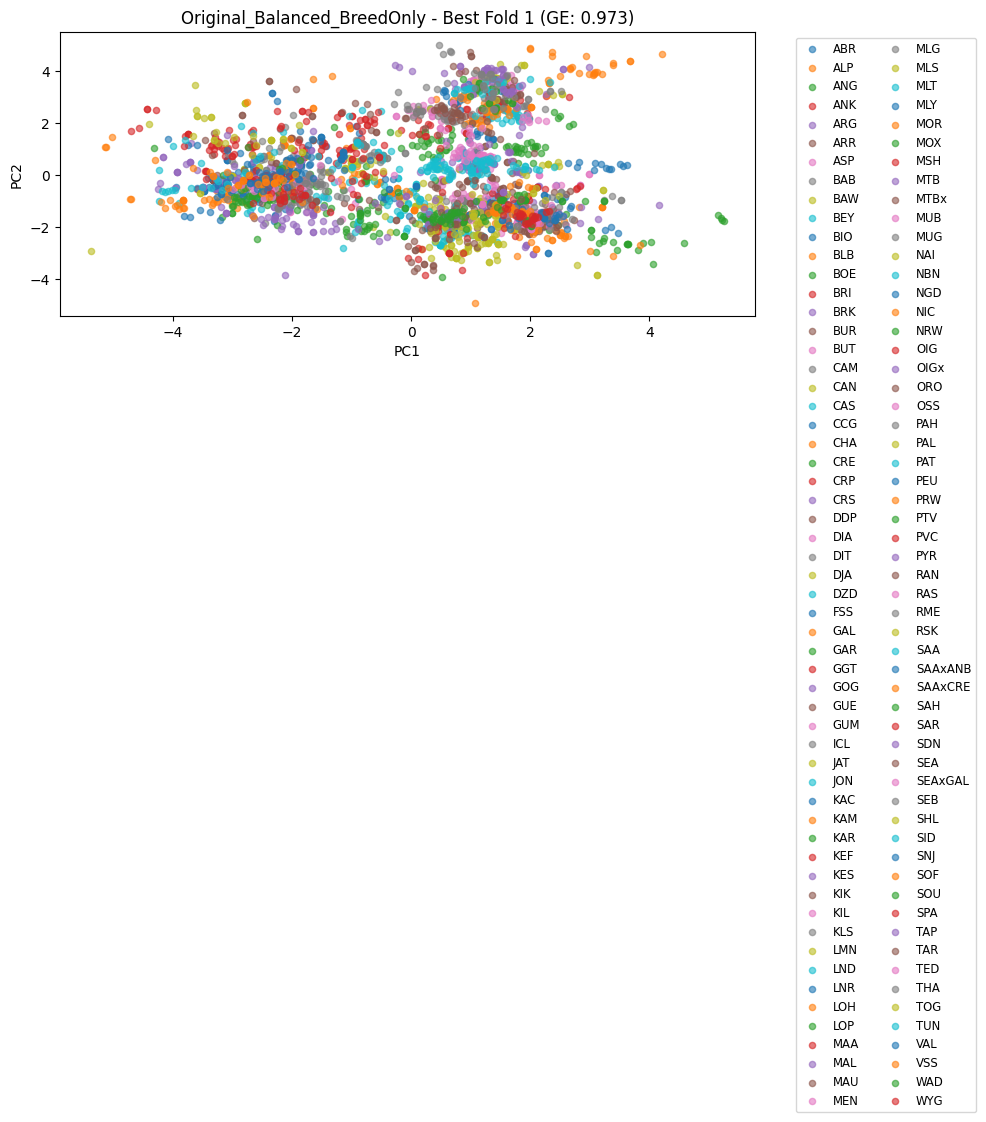

In [4]:
# 1. Original (Fine-Grained, Unbalanced) - Solo Breed
# res = run_experiment(
#     name="Original_Unbalanced_BreedOnly", 
#     config=config,
#     balanced=False, 
#     coarse_mapping=None, 
#     max_epochs=config['max_epochs'], 
#     classifier_config='breed_only'
# )

res1 = run_experiment(
    name="Original_Balanced_BreedOnly", 
    config=config,
    balanced=True, 
    coarse_mapping=None, 
    max_epochs=config['max_epochs'], 
    classifier_config='breed_only'
)
all_results.append(res1)

### 3.2 Esperimenti con Breed e Continent


🧪 EXPERIMENT: Original_Balanced_Breed+Continent
   Balanced: True
   Coarse Grained: False
   Classificatori: Breed=True, Continent=True, Caseina=False, Attitudine=False
   K-Fold CV: 2 folds


CARICAMENTO DATASET PLINK: ../data/ADAPTmap_genotypeTOP_20160222_full.bed
📋 Metadata caricato: 121 razze
📊 Shape iniziale: (4653, 53347) (4653 campioni, 53347 SNP)

🏷️  Estrazione label multiple...
   Continent: 3960/4653 campioni con label
   Caseina: 1191/4653 campioni con label
   Continenti: ['Africa', 'Asia', 'Europe']

🔍 Filtro Razze Rare (min 10 campioni):
   Razze valide: 114/144
   Campioni rimossi: 128

🧬 QUALITY CONTROL PIPELINE
────────────────────────────────────────────────────────────
1️⃣  Filtro Missingness SNP...
    ✓ Rimossi 2037 SNP con missingness >10.0%
2️⃣  Imputazione valori mancanti (media)...
    ✓ Imputazione completata
3️⃣  Filtro MAF (Minor Allele Frequency)...
    ✓ Rimossi 4 SNP con MAF <0.01
4️⃣  LD Pruning (Window=50, r²>0.2)...
    Device: cuda
    ...10000/513

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=100` reached.


   ✅ Fold 1 | GE: 0.9747 | Sil: 0.3763 | MSE: 0.3059 | Acc_Breed: 0.9772 | Acc_Cont: 0.9991

🔹 FOLD 2/2


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=100` reached.


   ✅ Fold 2 | GE: 0.9674 | Sil: 0.3702 | MSE: 0.3059 | Acc_Breed: 0.9758 | Acc_Cont: 0.9965

💾 Saved best checkpoint from Fold 1: checkpoints_vae/Original_Balanced_Breed+Continent/best_model.ckpt

📊 K-FOLD RESULTS (Mean ± Std):
   Local Structure (L): 0.9995 ± 0.0005
   Generalization (GE): 0.9711 ± 0.0037
   Silhouette: 0.3732 ± 0.0031
   Davies-Bouldin: 1.2129 ± 0.0016
   Reconstruction MSE: 0.3059 ± 0.0000
   NO_k3: 0.4645 ± 0.0048
   NO_k10: 0.4516 ± 0.0110
   NO_k30: 0.3184 ± 0.0127
   Acc_Breed: 0.9765 ± 0.0007
   Acc_Continent: 0.9978 ± 0.0013
   Best Fold: 1 (GE: 0.9747)

📈 Creating PCA visualization...


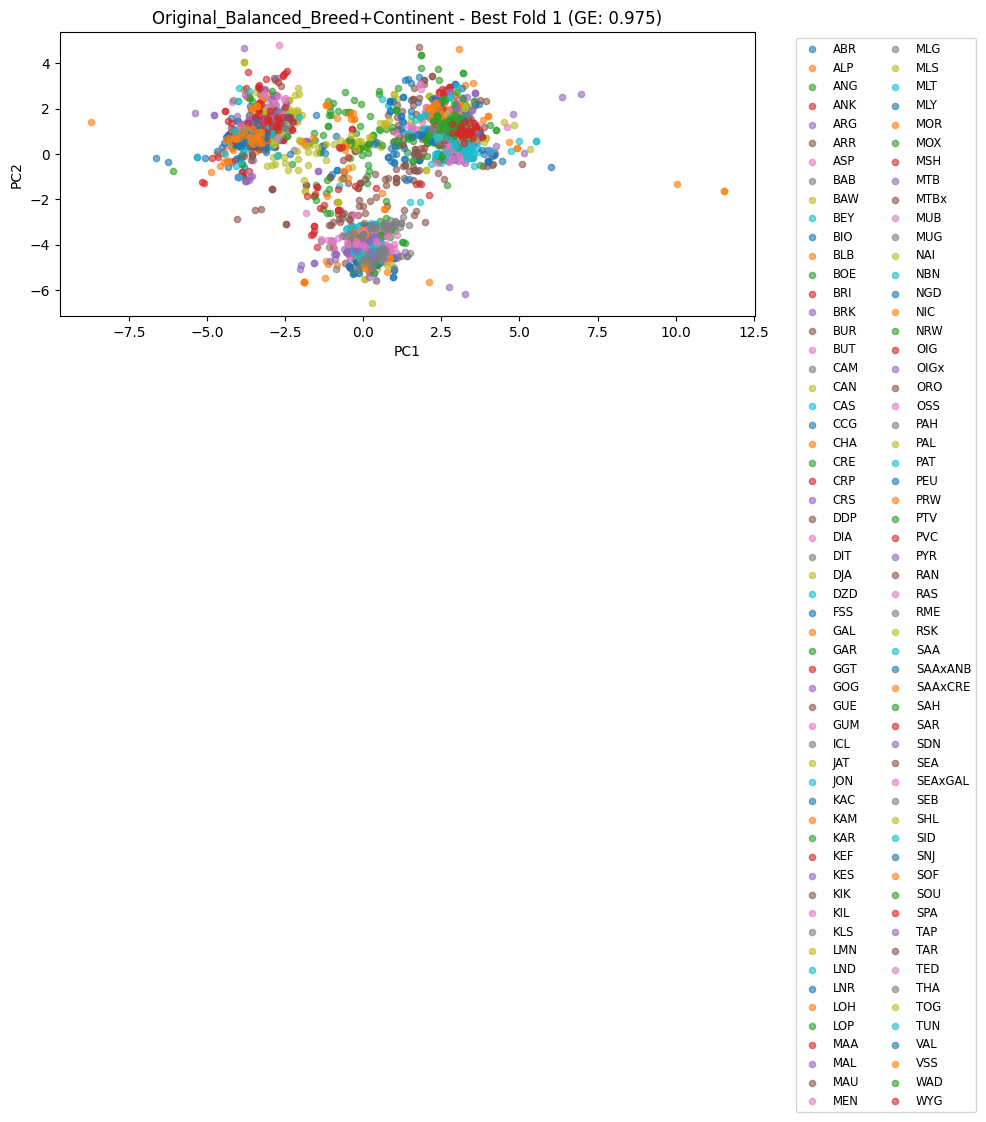

In [5]:
# 3. Original - Breed + Continent
res2 = run_experiment(
    name="Original_Balanced_Breed+Continent", 
    config=config,
    balanced=True, 
    coarse_mapping=None,
    max_epochs=config['max_epochs'], 
    classifier_config='breed_continent'
)
all_results.append(res2)

### 3.3 Esperimenti con Tutti i Classificatori

In [ ]:
# 4. Original - All Classifiers (Brreed + Continent + Caseina)
res4 = run_experiment(
    name="Original_Balanced_AllClassifiers", 
    config=config,
    balanced=True, 
    coarse_mapping=None,
    max_epochs=config['max_epochs'], 
    classifier_config='all_classifiers'
)
all_results.append(res4)


🧪 EXPERIMENT: Original_Balanced_AllClassifiers
   Balanced: True
   Coarse Grained: False
   Classificatori: Breed=True, Continent=True, Caseina=True, Attitudine=False
   K-Fold CV: 2 folds


CARICAMENTO DATASET PLINK: ../data/ADAPTmap_genotypeTOP_20160222_full.bed
📋 Metadata caricato: 121 razze
📊 Shape iniziale: (4653, 53347) (4653 campioni, 53347 SNP)

🏷️  Estrazione label multiple...
   Continent: 3960/4653 campioni con label
   Caseina: 1191/4653 campioni con label
   Continenti: ['Africa', 'Asia', 'Europe']
   Caseina: ['Debole', 'Forte', 'Medio']

🔍 Filtro Razze Rare (min 10 campioni):
   Razze valide: 114/144
   Campioni rimossi: 128

🧬 QUALITY CONTROL PIPELINE
────────────────────────────────────────────────────────────
1️⃣  Filtro Missingness SNP...
    ✓ Rimossi 2037 SNP con missingness >10.0%
2️⃣  Imputazione valori mancanti (media)...
    ✓ Imputazione completata
3️⃣  Filtro MAF (Minor Allele Frequency)...
    ✓ Rimossi 4 SNP con MAF <0.01
4️⃣  LD Pruning (Window=50, r²>0.

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


### 3.4 Esperimenti Solo VAE

In [ ]:
# 6. VAE Only (per confronto representation learning puro)
res6 = run_experiment(
    name="Original_Balanced_VAEOnly", 
    config=config,
    balanced=True, 
    coarse_mapping=None,
    max_epochs=config['max_epochs'], 
    classifier_config='vae_only'
)
all_results.append(res6)

## 4. Tabella Comparativa Risultati

In [ ]:
# --- COMPARISON TABLE ---
df_results = pd.DataFrame(all_results)
print("\n\n🏆 FINAL COMPARISON (VAE Multi-Task):")
print(df_results.to_string())

# Save results
df_results.to_csv("experiment_comparison_vae_multitask.csv", index=False)
print("\n✅ Results saved to experiment_comparison_vae_multitask.csv")

In [ ]:
# Visualizzazione tabella formattata
display_cols = [
    'Experiment', 
    'Generalization (GE) (mean)', 
    'Acc_Breed (mean)',
    'Silhouette (mean)',
    'Reconstruction MSE (mean)'
]
display_cols = [c for c in display_cols if c in df_results.columns]

df_results[display_cols].style.background_gradient(cmap='YlGn', subset=display_cols[1:])

## 5. Analisi Approfondita Modelli

Analisi dettagliata con matrici di confusione e metriche aggiuntive.

In [ ]:
from vae.analysis import run_full_analysis

# Lista esperimenti da analizzare
experiments_to_analyze = [
    "Original_Unbalanced_BreedOnly",
    "Original_Balanced_BreedOnly",
    "Original_Unbalanced_Breed+Continent",
    "Original_Unbalanced_AllClassifiers",
    "Original_Balanced_AllClassifiers",
    "Original_Unbalanced_VAEOnly",
    "Original_Unbalanced_ContinentOnly",
    "Original_Unbalanced_CaseinaOnly",
    # Aggiungi altri esperimenti se necessario
]

# Esegui analisi completa
df_analysis = run_full_analysis(
    experiments=experiments_to_analyze,
    config=config,
    coarse_mapping=COARSE_MAPPING,
    save_csv=True
)

## 6. Caricamento e Visualizzazione Modello Singolo

Per caricare e visualizzare un modello specifico già trainato.

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# Carica un modello specifico
EXPERIMENT_NAME = "Original_Balanced_BreedOnly"
checkpoint_path = f"checkpoints_vae/{EXPERIMENT_NAME}/best_model.ckpt"

if os.path.exists(checkpoint_path):
    print(f"📂 Caricamento modello: {checkpoint_path}")
    model = VMGP_LightningSystem.load_from_checkpoint(checkpoint_path)
    model.eval()
    model.freeze()
    
    print(f"✅ Modello caricato!")
    print(f"   Num SNPs: {model.hparams.num_snps}")
    print(f"   Num Classes Breed: {model.hparams.num_classes_breed}")
    print(f"   Use Breed: {model.use_breed}")
    print(f"   Use Continent: {model.use_continent}")
    print(f"   Use Caseina: {model.use_caseina}")
else:
    print(f"⚠️ Checkpoint non trovato: {checkpoint_path}")

In [ ]:
# Visualizzazione Latent Space con PCA
if 'model' in dir():
    # Carica dati
    dm = GenomicDataModule(
        bed_path=config['bed_path'],
        batch_size=config['batch_size'],
        maf_thresh=config['maf_thresh'],
        geno_thresh=config['geno_thresh'],
        min_samples_per_class=config['min_samples_per_class'],
        ld_pruning=config['ld_pruning'],
        ld_threshold=config['ld_threshold'],
        ld_window=config['ld_window'],
        metadata_path=config['metadata_path']
    )
    dm.setup()
    
    # Estrai embeddings
    embeddings = []
    labels = []
    
    with torch.no_grad():
        for batch in dm.val_dataloader():
            x = batch[0].to(model.device)
            outputs = model(x)
            embeddings.append(outputs['mu'].cpu().numpy())
            labels.append(batch[1].numpy())
    
    embeddings = np.concatenate(embeddings)
    labels = np.concatenate(labels)
    
    # PCA
    pca = PCA(n_components=2)
    emb_2d = pca.fit_transform(embeddings)
    
    # Plot
    plt.figure(figsize=(12, 10))
    unique_labels = np.unique(labels)
    
    for cls_idx in unique_labels:
        mask = labels == cls_idx
        label_name = dm.class_names_breed[cls_idx] if cls_idx < len(dm.class_names_breed) else str(cls_idx)
        plt.scatter(emb_2d[mask, 0], emb_2d[mask, 1], label=label_name, alpha=0.6, s=20)
    
    plt.title(f'Latent Space PCA - {EXPERIMENT_NAME}')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize='small')
    plt.tight_layout()
    plt.show()

---

## Note

- I checkpoint dei modelli sono salvati in `checkpoints_vae/<nome_esperimento>/`
- I risultati sono salvati in `experiment_comparison_vae_multitask.csv`
- I plot sono salvati come `plot_vae_<nome_esperimento>_kfold.png`